In [1]:
import os
import json

from PIL import Image
import pywt
import torch
from torchvision.transforms import v2

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_style("darkgrid")

In [2]:
print("Current Directory: ", os.getcwd())

Current Directory:  /home/alexandre/projects/qcop/notebooks


In [3]:
FILE = os.path.join("..", "data", "dataset.csv")

In [4]:
TARGET_DIR = os.path.join("out")

if(not os.path.exists(TARGET_DIR)):
    os.makedirs(TARGET_DIR)

In [5]:
df = pd.read_csv(FILE)
df.head()

,index,depth,file,result,hash,total_meas,measurements,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,amount_gates,file_size_bytes,n_barriers
0,21156,4,./data/images/21156.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",554ae38877eb15d7bb57f6fa666db46e,2,"[3, 4]",292,339,2,2,"{""cx"": 1, ""z"": 2, ""cz"": 1}",9692,0
1,51257,8,./data/images/51257.png,"[0.489, 0.511, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",1f7f11bb1848e714347b8f7224ad0463,2,"[3, 4]",775,339,9,1,"{""cx"": 6, ""h"": 1, ""cz"": 3}",19506,3
2,39279,4,./data/images/39279.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",5c26669fded6c02feb1bdcd54f54dc04,1,[2],292,339,2,3,"{""ry"": 1, ""cz"": 2, ""z"": 1, ""x"": 1}",9009,0
3,47283,6,./data/images/47283.png,"[0.035, 0.965, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",f72d34ff0fdf443d81820b4091c38e91,2,"[0, 4]",534,339,5,2,"{""cz"": 5, ""z"": 1, ""ry"": 1}",14167,1
4,53177,4,./data/images/53177.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3e21b0d13b73e89e5e3c9f1fb09890fe,2,"[2, 3]",485,339,4,1,"{""cz"": 3, ""cx"": 1, ""z"": 1}",13048,1


In [6]:
df.describe()

,index,depth,total_meas,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,file_size_bytes,n_barriers
count,56761.000000,56761.000000,56761.000000,56761.000000,56761.0,56761.000000,56761.000000,56761.000000,56761.000000
mean,31073.131076,7.328289,2.580645,614.505312,339.0,5.395958,5.375205,16726.700499,1.113053
std,18062.198335,3.526155,1.040300,233.978622,0.0,3.299726,3.270908,4799.369209,1.159493
min,0.000000,1.000000,1.000000,147.000000,339.0,0.000000,0.000000,4652.000000,0.000000
25%,15180.000000,4.000000,2.000000,437.000000,339.0,3.000000,3.000000,12873.000000,0.000000
50%,31040.000000,7.000000,3.000000,582.000000,339.0,5.000000,5.000000,16825.000000,1.000000
75%,46804.000000,10.000000,3.000000,775.000000,339.0,8.000000,8.000000,20485.000000,2.000000
max,61999.000000,18.000000,5.000000,1306.000000,339.0,17.000000,16.000000,32472.000000,6.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56761 entries, 0 to 56760
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   index              56761 non-null  int64 
 1   depth              56761 non-null  int64 
 2   file               56761 non-null  object
 3   result             56761 non-null  object
 4   hash               56761 non-null  object
 5   total_meas         56761 non-null  int64 
 6   measurements       56761 non-null  object
 7   img_width          56761 non-null  int64 
 8   img_height         56761 non-null  int64 
 9   n_two_qubit_gates  56761 non-null  int64 
 10  n_one_qubit_gates  56761 non-null  int64 
 11  amount_gates       56761 non-null  object
 12  file_size_bytes    56761 non-null  int64 
 13  n_barriers         56761 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 6.1+ MB


There're some things we could think of it, maybe the distribution of one and two qubit gates, amount of barriers distribution as well, depth, etc.

---

In [8]:
def distribution_of_type_of_gates(df:pd.DataFrame):
    fig,ax = plt.subplots(1,2, figsize=(15,5))

    for i, (key, text) in enumerate(zip(("n_one_qubit_gates", "n_two_qubit_gates"), ("one qubit gates", "two qubit gates"))):
        values = sorted(list(df[key].unique()))
        mean = df[key].value_counts().mean()
        median = df[key].value_counts().median()
        
        sns.histplot(data=df, x=key, binwidth=1, ax=ax[i])
        ax[i].set_xticks(values)
        ax[i].set_title(f"Distribution of {text}")
        ax[i].axhline(y=mean, color='red', linestyle='--', linewidth=1.5, label="mean")
        ax[i].axhline(y=median, color='orange', linestyle='--', linewidth=1.5, label="median")
        ax[i].set_xlabel("")
        
        if(i == 1):
            ax[i].set_ylabel("")
    
    plt.legend()
    plt.show()

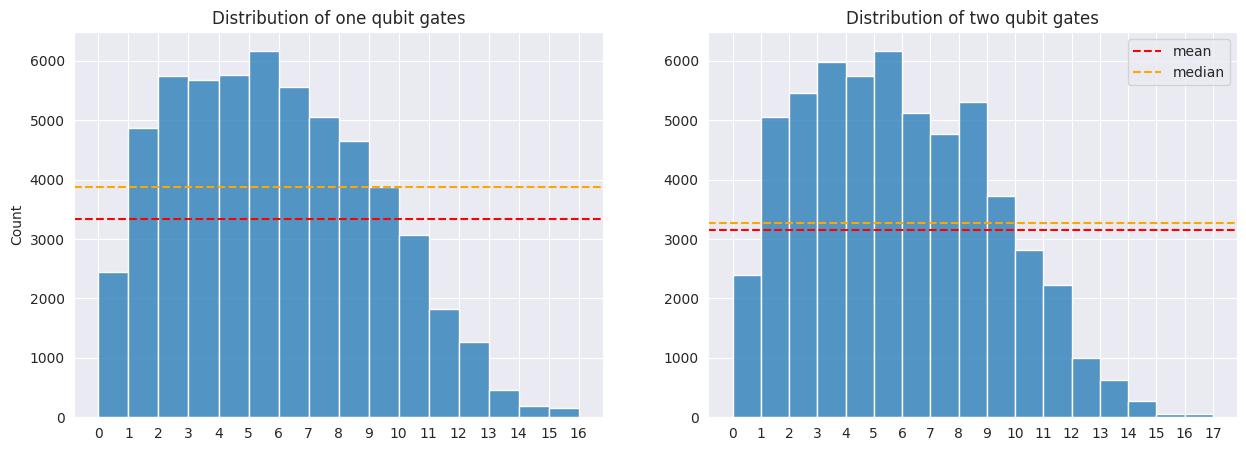

In [9]:
distribution_of_type_of_gates(df)

It's may be necessary to balance the distribution of this kind of data, since most part of the circuits are centered in the range of $1$-$9$ gates

---

In [10]:
gate_data = df['amount_gates'].apply(json.loads)
gates_json = pd.json_normalize(gate_data).fillna(0)
display(gates_json.head())
gates_json.describe()

,cx,cz,ry,id,z,x,h
0,4.0,5.0,1.0,1.0,1.0,1.0,1.0
1,1.0,2.0,0.0,0.0,0.0,0.0,0.0
2,1.0,5.0,5.0,1.0,0.0,1.0,1.0
3,3.0,5.0,6.0,3.0,1.0,2.0,0.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0


,cx,cz,ry,id,z,x,h
count,56761.000000,56761.000000,56761.000000,56761.000000,56761.000000,56761.000000,56761.000000
mean,2.702895,2.693064,1.123430,1.045330,1.103222,1.044238,1.058984
std,2.040618,1.973282,1.133412,1.101926,1.175839,1.134210,1.124104
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,4.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,15.000000,13.000000,6.000000,8.000000,7.000000,8.000000,7.000000


For some reason, two qubit gates are used more than single qubits ones. This may be some error in the code, or some imbalanced dataset clues.

In [11]:
def gates_distribution(df:pd.DataFrame):
    gate_data = df['amount_gates'].apply(json.loads)
    gates_json = pd.json_normalize(gate_data).fillna(0)
    dataset = gates_json.melt(var_name="gate", value_name="value")\
                        .groupby("gate")["value"].sum().reset_index()

    sns.barplot(data=dataset, y="value",x="gate",hue="gate")
    
    median = dataset.value.median()
    mean = dataset.value.mean()
    
    plt.axhline(y=mean, color='red', linestyle='--', linewidth=1.5, label="mean")
    plt.axhline(y=median, color='orange', linestyle='--', linewidth=1.5, label="median")
    
    plt.legend()
    plt.show()

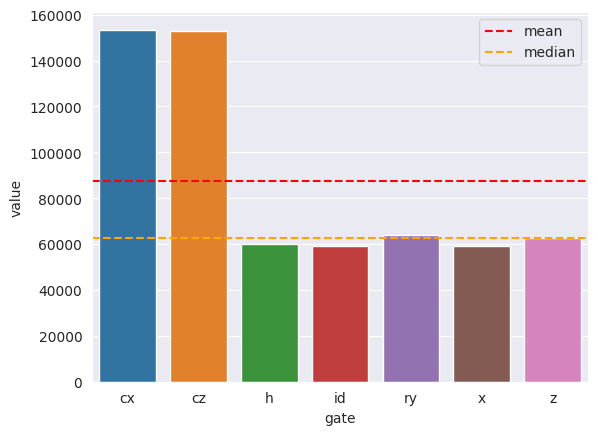

In [12]:
gates_distribution(df)

In [79]:
def depth_dist(df:pd.DataFrame):
    median = df.depth.value_counts().median()
    mean = df.depth.value_counts().mean()
    
    sns.histplot(data=df, x="depth",binwidth=1)
    plt.xticks(sorted(df.depth.unique()))
    plt.xticks(rotation=90)
    plt.axhline(y=mean, color='red', linestyle='--', linewidth=1.5, label="mean")
    plt.axhline(y=median, color='orange', linestyle='--', linewidth=1.5, label="median")

    plt.legend()
    plt.show()

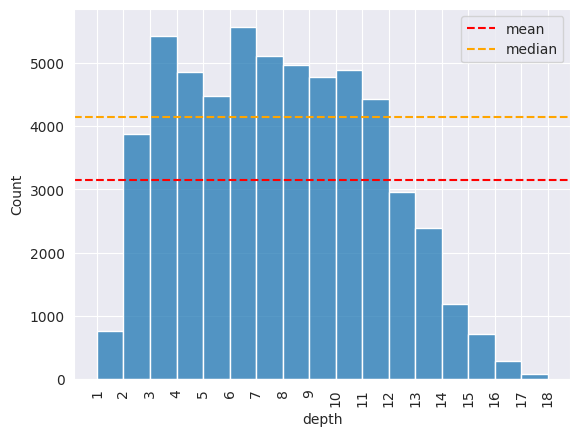

In [80]:
depth_dist(df)

One hypothesis is that reducing the depth outliers we can approximate the dataset to a more standardized version

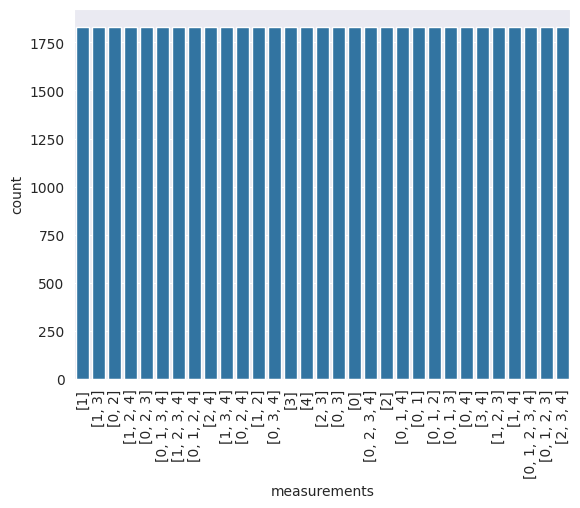

In [15]:
sns.countplot(data=df,x="measurements")
plt.xticks(rotation=90)
plt.show()

Since we are mapping through all different combinations of measurements, this part is balanced


---
# Testing a cut on the depth

In [16]:
min_depth = 2
max_depth = 11

In [17]:
cut_df = df[(df["depth"] >= min_depth) & (df["depth"] <= max_depth)]
cut_df.head()

,index,depth,file,result,hash,total_meas,measurements,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,amount_gates,file_size_bytes,n_barriers
0,60761,9,./data/images/60761.png,"[0.505, 0.495, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",2f9b684731c2bff8234ea0e8c5ac5100,1,[1],534,339,9,5,"{""cx"": 4, ""cz"": 5, ""ry"": 1, ""id"": 1, ""z"": 1, ""...",15624,0
1,20687,3,./data/images/20687.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",70dff562ff0b2fb0090cfe94dcd44d9d,2,"[1, 3]",292,339,3,0,"{""cz"": 2, ""cx"": 1}",9787,0
3,19831,10,./data/images/19831.png,"[0.024, 0.026, 0.404, 0.546, 0.0, 0.0, 0.0, 0....",887bf6611e09a13235089ed54410a57b,3,"[1, 2, 4]",727,339,8,12,"{""ry"": 6, ""cz"": 5, ""id"": 3, ""x"": 2, ""z"": 1, ""c...",22672,1
4,58736,2,./data/images/58736.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",527369351227ba8bdbffec87a52238f1,3,"[1, 2, 4]",292,339,1,1,"{""ry"": 1, ""cz"": 1}",10163,0
5,8915,2,./data/images/8915.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",fa4063d1398446279378d4cd236b552c,3,"[0, 2, 3]",244,339,0,2,"{""id"": 1, ""z"": 1}",9042,0


In [18]:
cut_df.describe()

,index,depth,total_meas,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,file_size_bytes,n_barriers
count,48386.000000,48386.000000,48386.000000,48386.000000,48386.0,48386.000000,48386.000000,48386.000000,48386.000000
mean,31277.222957,6.518931,2.579444,566.118402,339.0,4.757575,5.011553,15895.458356,0.974373
std,18045.181378,2.797322,1.039959,195.966989,0.0,2.813607,3.160384,4258.187243,1.055651
min,62.000000,2.000000,1.000000,196.000000,339.0,0.000000,0.000000,5860.000000,0.000000
25%,15287.250000,4.000000,2.000000,389.000000,339.0,2.000000,2.000000,12493.000000,0.000000
50%,31408.500000,6.000000,3.000000,582.000000,339.0,5.000000,5.000000,15954.000000,1.000000
75%,47115.750000,9.000000,3.000000,727.000000,339.0,7.000000,7.000000,19151.000000,1.000000
max,61999.000000,11.000000,5.000000,1210.000000,339.0,13.000000,16.000000,29100.000000,6.000000


In [19]:
cut_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48386 entries, 0 to 56760
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   index              48386 non-null  int64 
 1   depth              48386 non-null  int64 
 2   file               48386 non-null  object
 3   result             48386 non-null  object
 4   hash               48386 non-null  object
 5   total_meas         48386 non-null  int64 
 6   measurements       48386 non-null  object
 7   img_width          48386 non-null  int64 
 8   img_height         48386 non-null  int64 
 9   n_two_qubit_gates  48386 non-null  int64 
 10  n_one_qubit_gates  48386 non-null  int64 
 11  amount_gates       48386 non-null  object
 12  file_size_bytes    48386 non-null  int64 
 13  n_barriers         48386 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 5.5+ MB


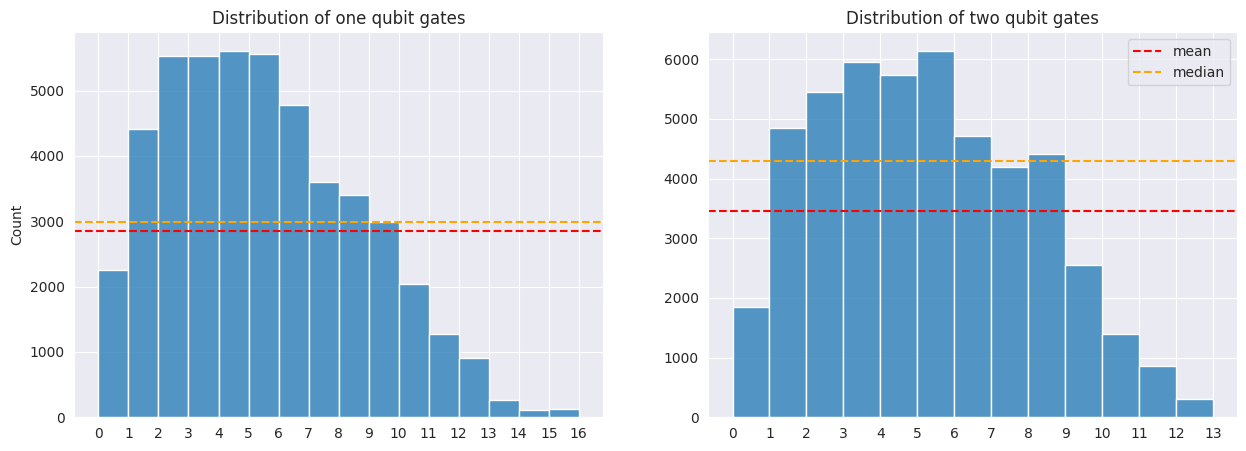

In [20]:
distribution_of_type_of_gates(cut_df)

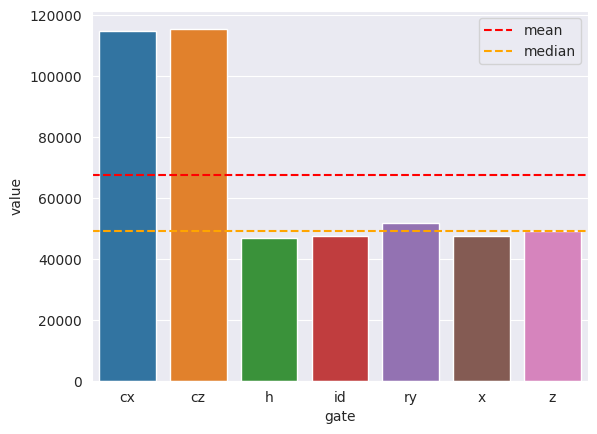

In [21]:
gates_distribution(cut_df)

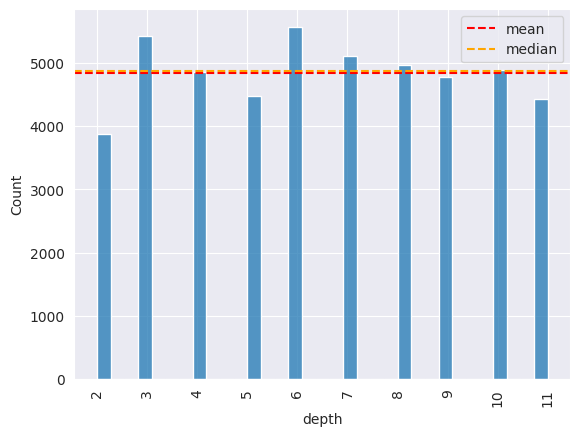

In [22]:
depth_dist(cut_df)

---

## Another Cut Test


In [85]:
_25 = df.depth.describe().loc['25%']
_75 = df.depth.describe().loc['75%']
print("0.25 percentile: ", _25)
print("0.75 percentile: ", _75)

0.25 percentile:  4.0
0.75 percentile:  10.0


In [86]:
cut_df = df[(df["depth"] >= _25) & (df["depth"] <= _75)]
cut_df.head()

,index,depth,file,result,hash,total_meas,measurements,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,amount_gates,file_size_bytes,n_barriers
0,60761,9,./data/images/60761.png,"[0.505, 0.495, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",2f9b684731c2bff8234ea0e8c5ac5100,1,[1],534,339,9,5,"{""cx"": 4, ""cz"": 5, ""ry"": 1, ""id"": 1, ""z"": 1, ""...",15624,0
3,19831,10,./data/images/19831.png,"[0.024, 0.026, 0.404, 0.546, 0.0, 0.0, 0.0, 0....",887bf6611e09a13235089ed54410a57b,3,"[1, 2, 4]",727,339,8,12,"{""ry"": 6, ""cz"": 5, ""id"": 3, ""x"": 2, ""z"": 1, ""c...",22672,1
6,37010,6,./data/images/37010.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",963a1da088a2293262397448cf8851a9,4,"[0, 1, 3, 4]",582,339,4,4,"{""x"": 1, ""z"": 2, ""cx"": 3, ""cz"": 1, ""ry"": 1}",18188,1
8,60290,4,./data/images/60290.png,"[0.505, 0.495, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",8df1ed87f618aebdf5ad3371349e857e,4,"[0, 1, 2, 4]",534,339,1,4,"{""z"": 1, ""x"": 2, ""cz"": 1, ""h"": 1}",14665,2
9,30300,10,./data/images/30300.png,"[0.02, 0.98, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",cf12e78ebd67cd0c51a3ad84a6027524,2,"[2, 4]",630,339,7,4,"{""z"": 1, ""ry"": 1, ""x"": 1, ""cz"": 3, ""cx"": 4, ""i...",15973,0


In [87]:
cut_df.describe()

,index,depth,total_meas,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,file_size_bytes,n_barriers
count,34659.000000,34659.000000,34659.000000,34659.000000,34659.0,34659.000000,34659.000000,34659.000000,34659.000000
mean,31287.653221,7.002712,2.582273,597.262702,339.0,5.204074,5.487781,16639.225598,1.052483
std,17845.184943,1.976109,1.040472,151.876438,0.0,2.300042,2.859803,3356.845648,1.030796
min,62.000000,4.000000,1.000000,292.000000,339.0,0.000000,0.000000,7142.000000,0.000000
25%,15723.500000,5.000000,2.000000,485.000000,339.0,3.000000,3.000000,14157.000000,0.000000
50%,31078.000000,7.000000,3.000000,582.000000,339.0,5.000000,5.000000,16617.000000,1.000000
75%,46980.500000,9.000000,3.000000,727.000000,339.0,7.000000,7.000000,19050.000000,2.000000
max,61999.000000,10.000000,5.000000,1113.000000,339.0,13.000000,16.000000,29100.000000,6.000000


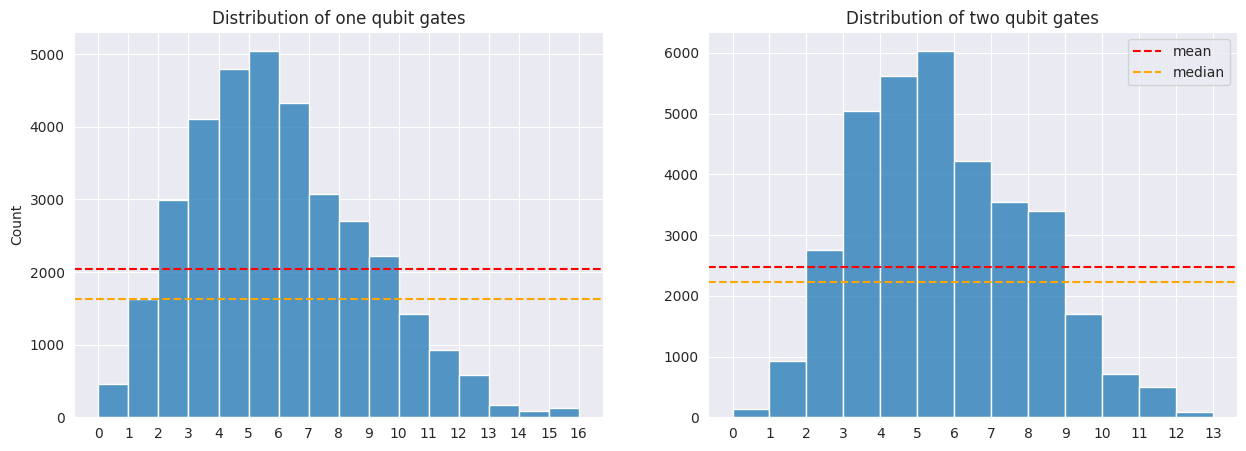

In [88]:
distribution_of_type_of_gates(cut_df)

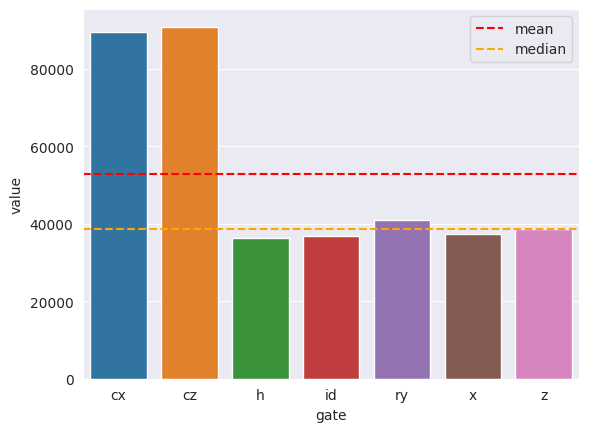

In [89]:
gates_distribution(cut_df)

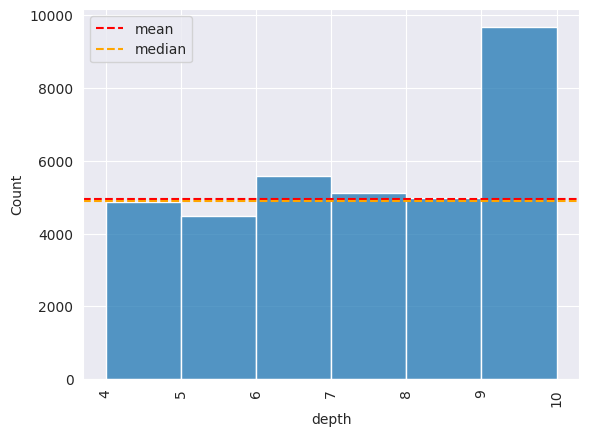

In [90]:
depth_dist(cut_df)

---

# Understanding the distribution between gates

In [23]:
gate_data = df['amount_gates'].apply(json.loads)
gates_json = pd.json_normalize(gate_data).fillna(0)
display(gates_json.head())
gates_json.describe()

,cx,cz,ry,id,z,x,h
0,4.0,5.0,1.0,1.0,1.0,1.0,1.0
1,1.0,2.0,0.0,0.0,0.0,0.0,0.0
2,1.0,5.0,5.0,1.0,0.0,1.0,1.0
3,3.0,5.0,6.0,3.0,1.0,2.0,0.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0


,cx,cz,ry,id,z,x,h
count,56761.000000,56761.000000,56761.000000,56761.000000,56761.000000,56761.000000,56761.000000
mean,2.702895,2.693064,1.123430,1.045330,1.103222,1.044238,1.058984
std,2.040618,1.973282,1.133412,1.101926,1.175839,1.134210,1.124104
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,4.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,15.000000,13.000000,6.000000,8.000000,7.000000,8.000000,7.000000


In [24]:
two_qgates_above_avg = gates_json[(gates_json["cx"] > gates_json["cx"].mean()) | (gates_json["cz"] > gates_json["cz"].mean())].fillna(0)
display(two_qgates_above_avg.head())
two_qgates_above_avg.describe()

,cx,cz,ry,id,z,x,h
0,4.0,5.0,1.0,1.0,1.0,1.0,1.0
2,1.0,5.0,5.0,1.0,0.0,1.0,1.0
3,3.0,5.0,6.0,3.0,1.0,2.0,0.0
6,3.0,1.0,1.0,0.0,2.0,1.0,0.0
7,4.0,2.0,3.0,1.0,3.0,0.0,2.0


,cx,cz,ry,id,z,x,h
count,36797.000000,36797.000000,36797.000000,36797.000000,36797.000000,36797.000000,36797.000000
mean,3.640270,3.609099,1.385004,1.256108,1.359730,1.275484,1.336984
std,1.895214,1.814184,1.174389,1.136136,1.227817,1.172186,1.163634
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,5.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,15.000000,13.000000,6.000000,8.000000,7.000000,8.000000,6.000000


In [56]:
def plot_gates_list_distribution(df:pd.DataFrame):
    gates_part = df[["n_two_qubit_gates", "n_one_qubit_gates"]]
    std = gates_part.std()
    gates_list = gates_part.stack().reset_index().drop(columns=["level_0"]).rename(columns={"level_1":"type", 0:"quantity"})
    
    sns.histplot(data=gates_list, x="quantity",hue="type")
    plt.axvline(x=std["n_one_qubit_gates"], linestyle="--", linewidth=2, color="red", label="std_one_qubit_gates")
    plt.axvline(x=std["n_two_qubit_gates"], linestyle="--", linewidth=2, color="orange", label="std_two_qubit_gates")

    plt.xticks(list(gates_list.quantity.unique()), rotation=90)
    #plt.legend()
    plt.show()

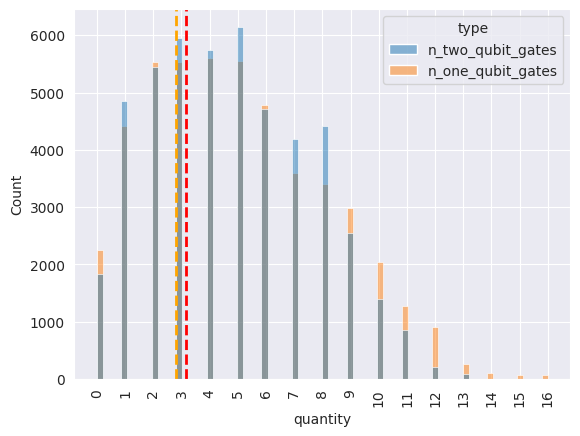

In [57]:
plot_gates_list_distribution(cut_df)

In [59]:
clean_gates_quantity = cut_df[(cut_df["n_one_qubit_gates"] < 12) & (cut_df["n_two_qubit_gates"] < 12)]
clean_gates_quantity.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46674 entries, 0 to 56760
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   index              46674 non-null  int64 
 1   depth              46674 non-null  int64 
 2   file               46674 non-null  object
 3   result             46674 non-null  object
 4   hash               46674 non-null  object
 5   total_meas         46674 non-null  int64 
 6   measurements       46674 non-null  object
 7   img_width          46674 non-null  int64 
 8   img_height         46674 non-null  int64 
 9   n_two_qubit_gates  46674 non-null  int64 
 10  n_one_qubit_gates  46674 non-null  int64 
 11  amount_gates       46674 non-null  object
 12  file_size_bytes    46674 non-null  int64 
 13  n_barriers         46674 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 5.3+ MB


In [60]:
clean_gates_quantity.describe()

,index,depth,total_meas,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,file_size_bytes,n_barriers
count,46674.000000,46674.000000,46674.000000,46674.000000,46674.0,46674.000000,46674.000000,46674.000000,46674.000000
mean,31204.633265,6.396302,2.581159,557.936003,339.0,4.676222,4.781356,15718.048207,0.953100
std,18108.115636,2.763058,1.039934,193.424592,0.0,2.775632,2.911450,4204.706847,1.045003
min,62.000000,2.000000,1.000000,196.000000,339.0,0.000000,0.000000,5860.000000,0.000000
25%,15047.000000,4.000000,2.000000,389.000000,339.0,2.000000,2.000000,12355.250000,0.000000
50%,31279.500000,6.000000,3.000000,534.000000,339.0,4.000000,5.000000,15727.500000,1.000000
75%,47167.750000,9.000000,3.000000,727.000000,339.0,7.000000,7.000000,18911.000000,1.000000
max,61999.000000,11.000000,5.000000,1210.000000,339.0,11.000000,11.000000,29100.000000,6.000000


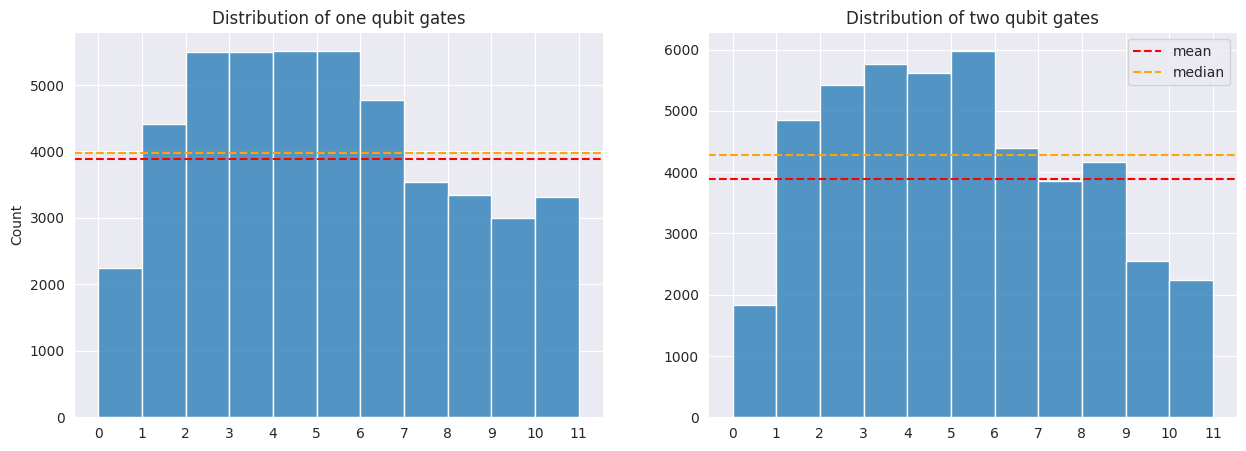

In [61]:
distribution_of_type_of_gates(clean_gates_quantity)

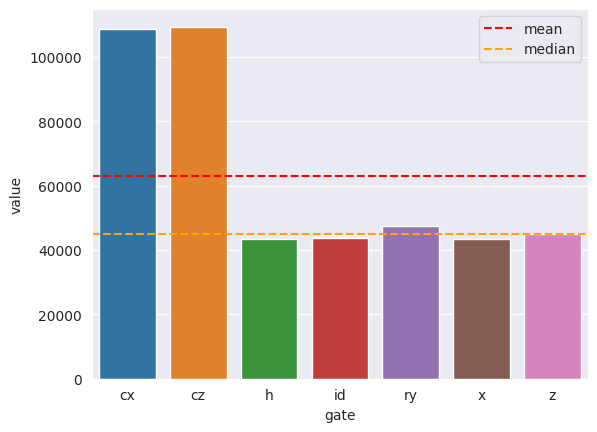

In [62]:
gates_distribution(clean_gates_quantity)

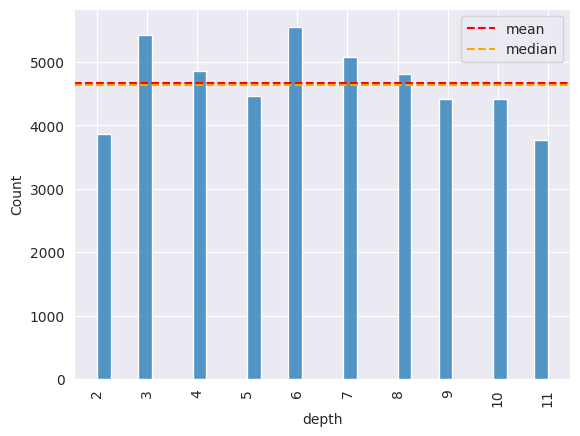

In [63]:
depth_dist(clean_gates_quantity)

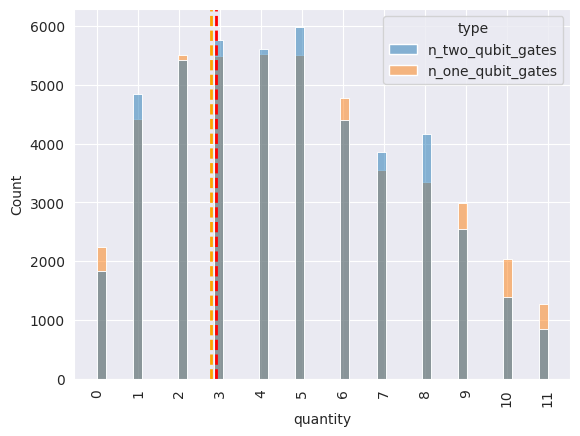

In [64]:
plot_gates_list_distribution(clean_gates_quantity)

---

# Test the usage of Wavelets Transform

Shape:  (339, 1065)
uint8


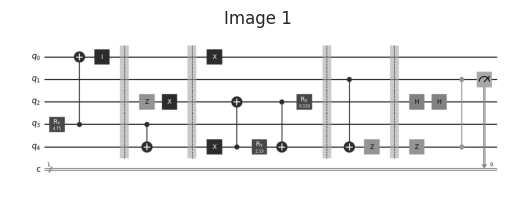

In [2]:
oimg = Image.open(os.path.join("..", "data", "images", "1.png")).convert('L')
ex_image = np.asarray(oimg)

print("Shape: ", ex_image.shape)
print(ex_image.dtype)

plt.imshow(ex_image, cmap="grey")
plt.title("Image 1")
plt.axis("off")
plt.show()

Recursive decompositions of cA


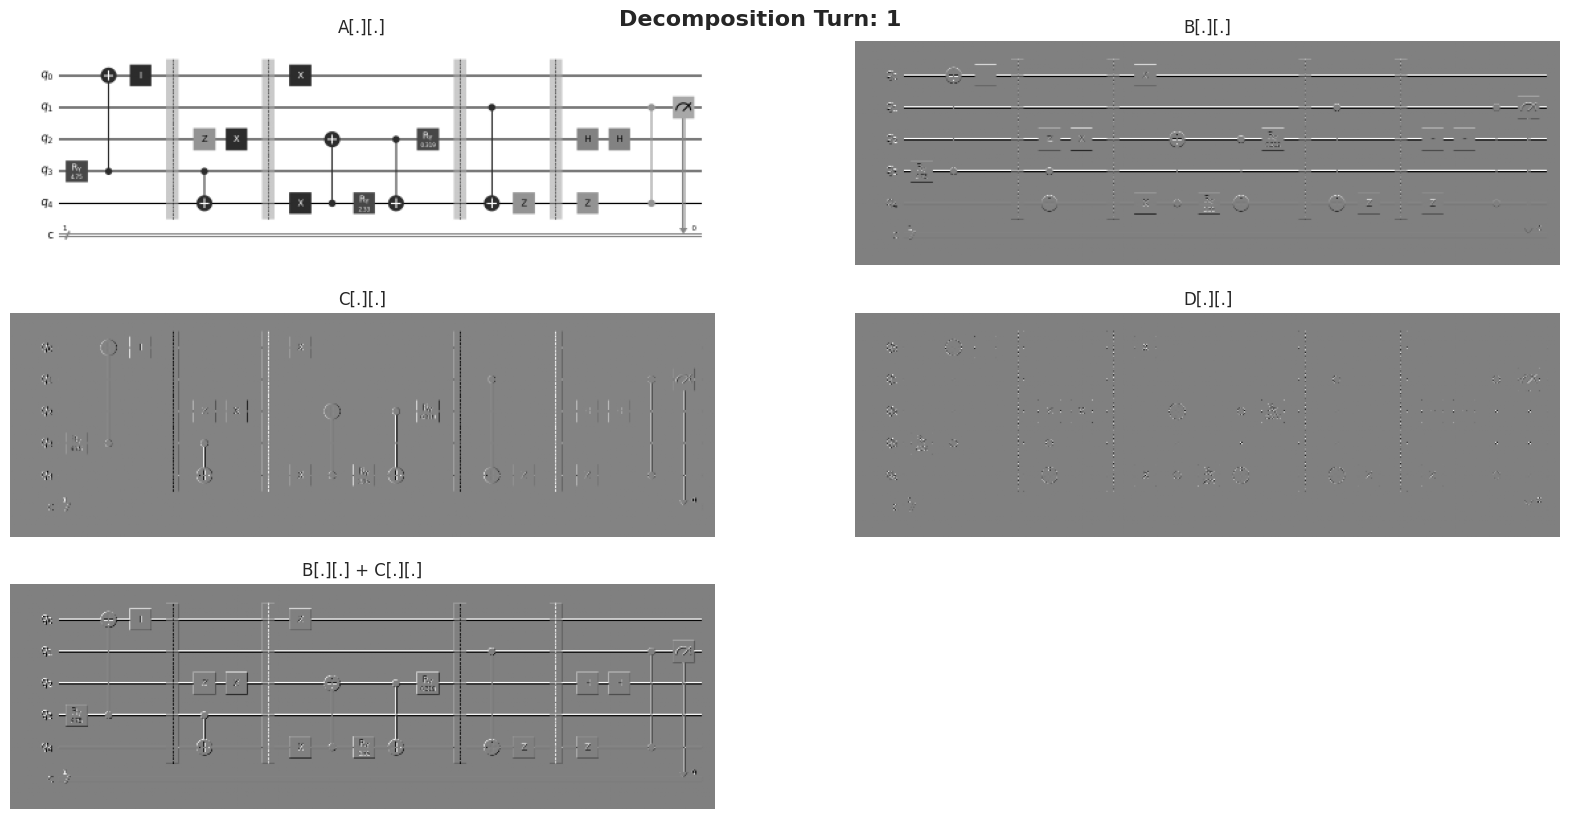

Shape A[.][.] (170, 533)


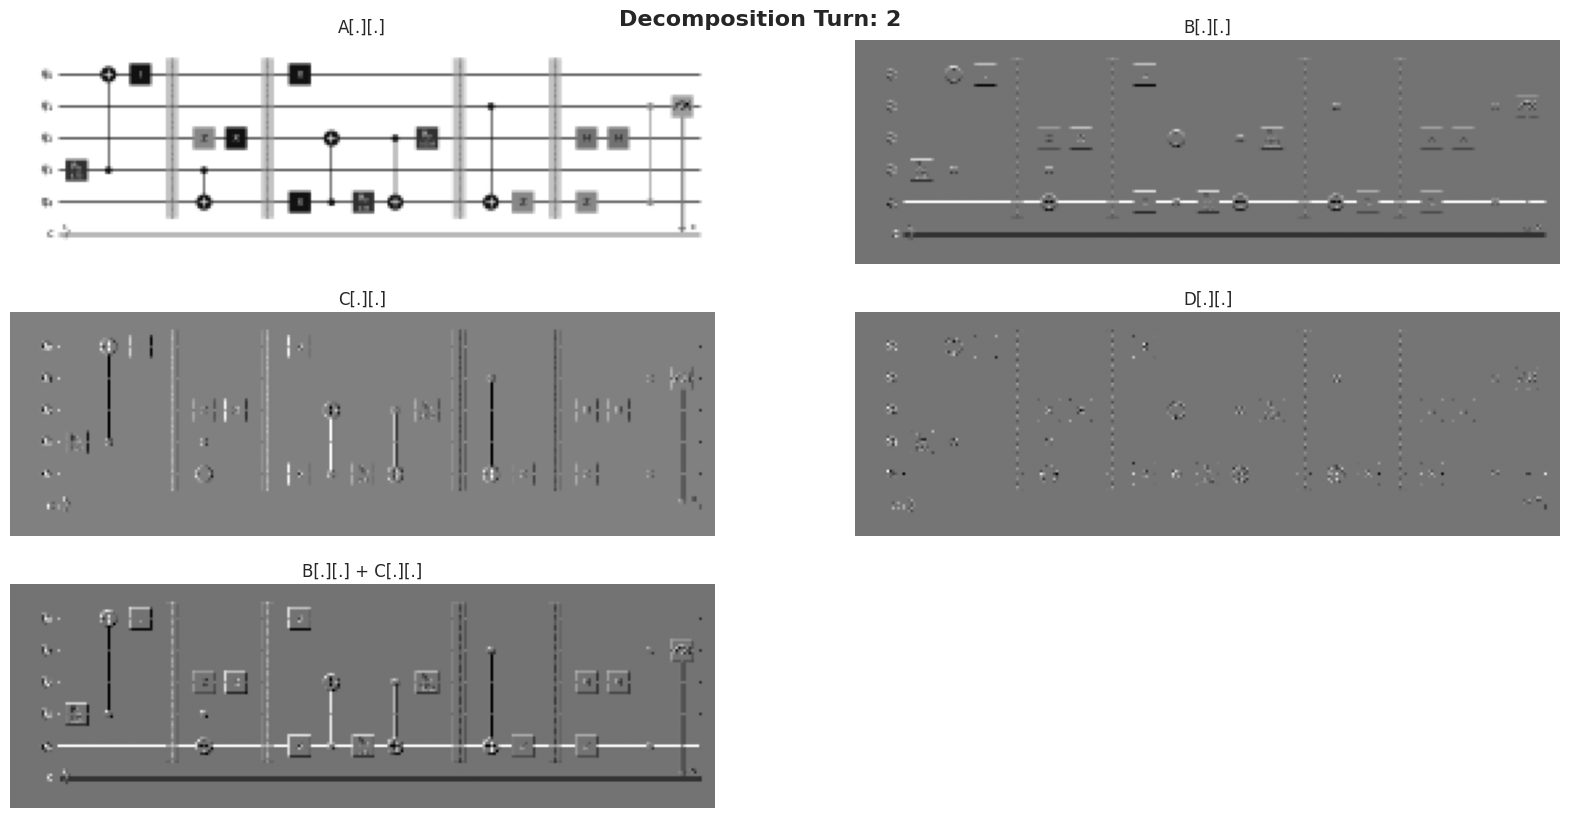

Shape A[.][.] (85, 267)


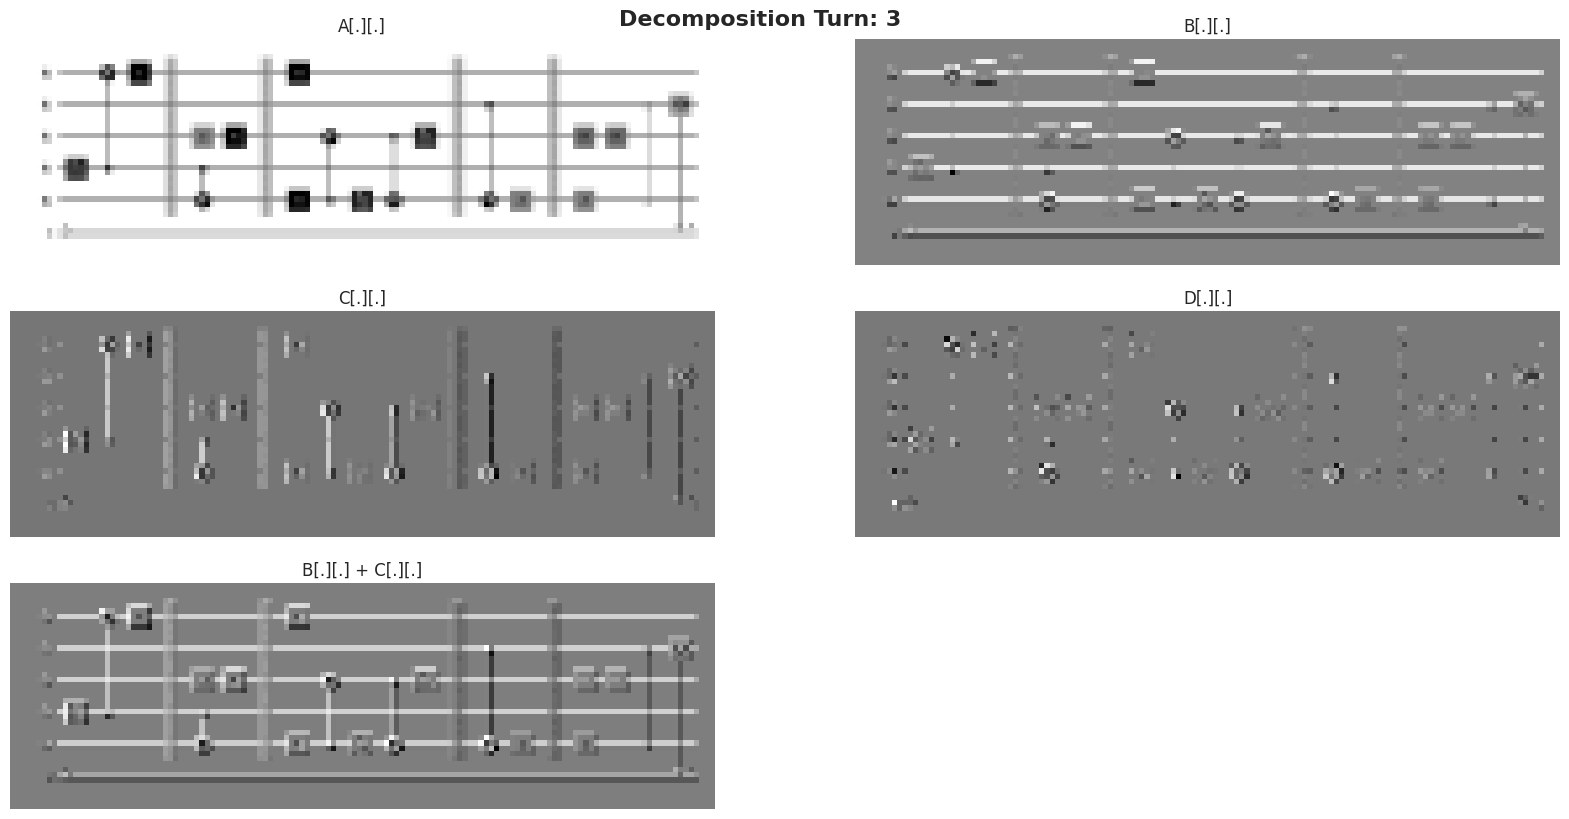

Shape A[.][.] (43, 134)


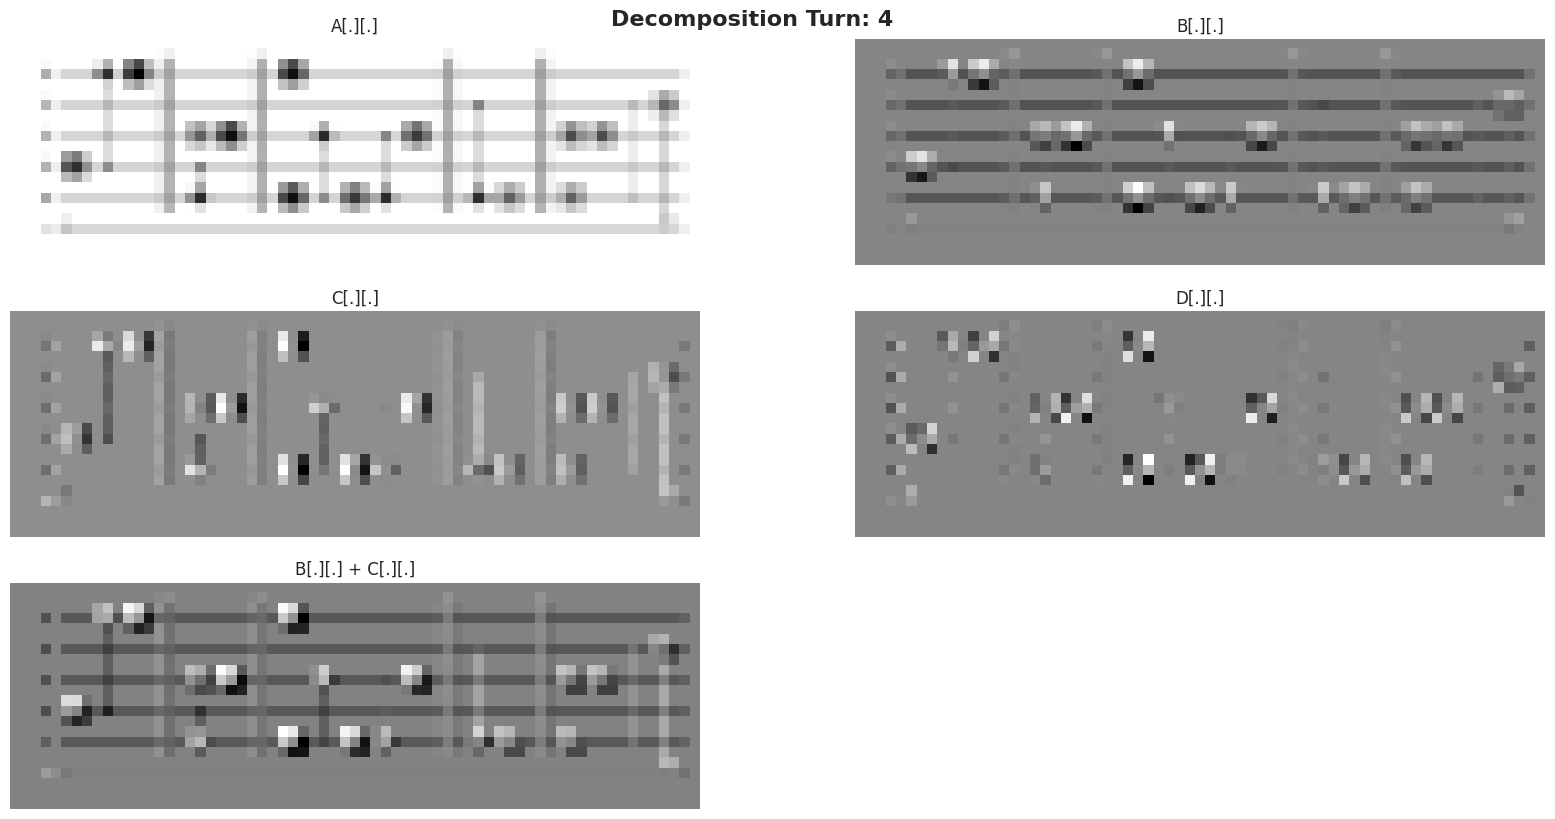

Shape A[.][.] (22, 67)


In [72]:
print("Recursive decompositions of cA")
img = ex_image

for turn in range(4):
    coeffs = pywt.dwt2(img, 'Haar')
    cA, (cB, cC, cD) = coeffs
    
    fig,axs = plt.subplots(3,2,figsize=(20,10))
    axs[2,1].set_visible(False)

    
    parts = [
        ("A[.][.]", cA), 
        ("B[.][.]", cB), 
        ("C[.][.]", cC), 
        ("D[.][.]", cD), 
    ]
    
    for i in range(2):
        for j in range(2):
            part_index = i*2 + j
            ax = axs[i,j]
    
            title,part = parts[part_index]
            ax.imshow(part,cmap="grey")
            ax.set_title(title)
            ax.axis("off")
            
    axs[2,0].imshow(cB+cC,cmap="grey")
    axs[2,0].set_title("B[.][.] + C[.][.]")
    axs[2,0].axis("off") 
        
    plt.suptitle(f"Decomposition Turn: {turn+1}", fontsize=16, y=0.91, fontweight="bold")
    fig.savefig(os.path.join(TARGET_DIR,f"decomposition-turn-{turn+1}.png"),bbox_inches="tight")
    plt.show()

    print("Shape A[.][.]", cA.shape)

    img = cA

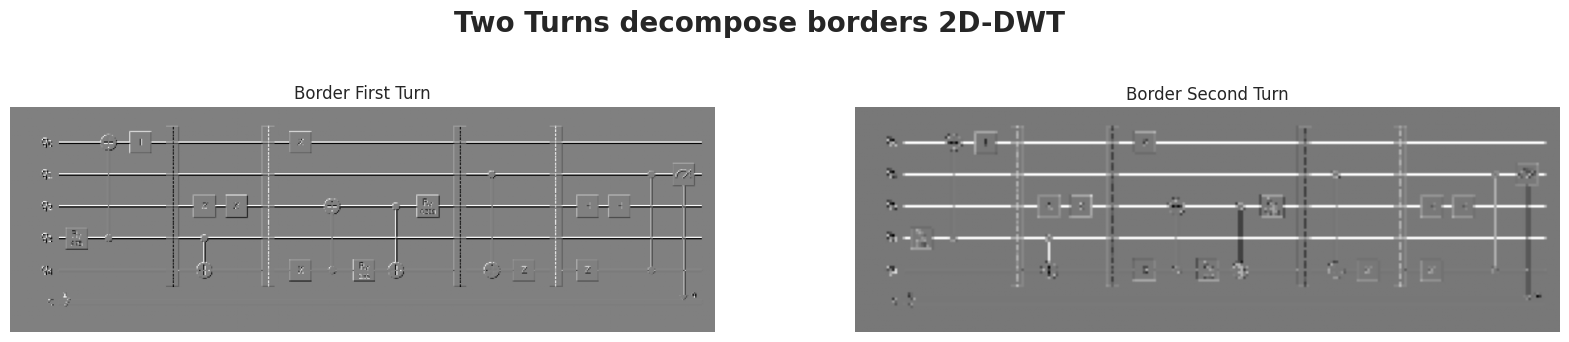

In [71]:
cA, (cB, cC, cD) = pywt.dwt2(ex_image, 'Haar')
border1 = cB+cC

cA, (cB, cC, cD) = pywt.dwt2(border1, 'Haar')
border2 = cB+cC

fig,axs = plt.subplots(1,2,figsize=(20,20))
axs[0].imshow(border1, cmap="grey")
axs[0].set_title("Border First Turn")
axs[0].axis("off")


axs[1].imshow(border2, cmap="grey")
axs[1].set_title("Border Second Turn")
axs[1].axis("off")

plt.suptitle("Two Turns decompose borders 2D-DWT", y=0.6, fontsize=20, fontweight="bold")
fig.savefig(os.path.join(TARGET_DIR,"two-decompose-borders.png"),bbox_inches="tight")
plt.show()

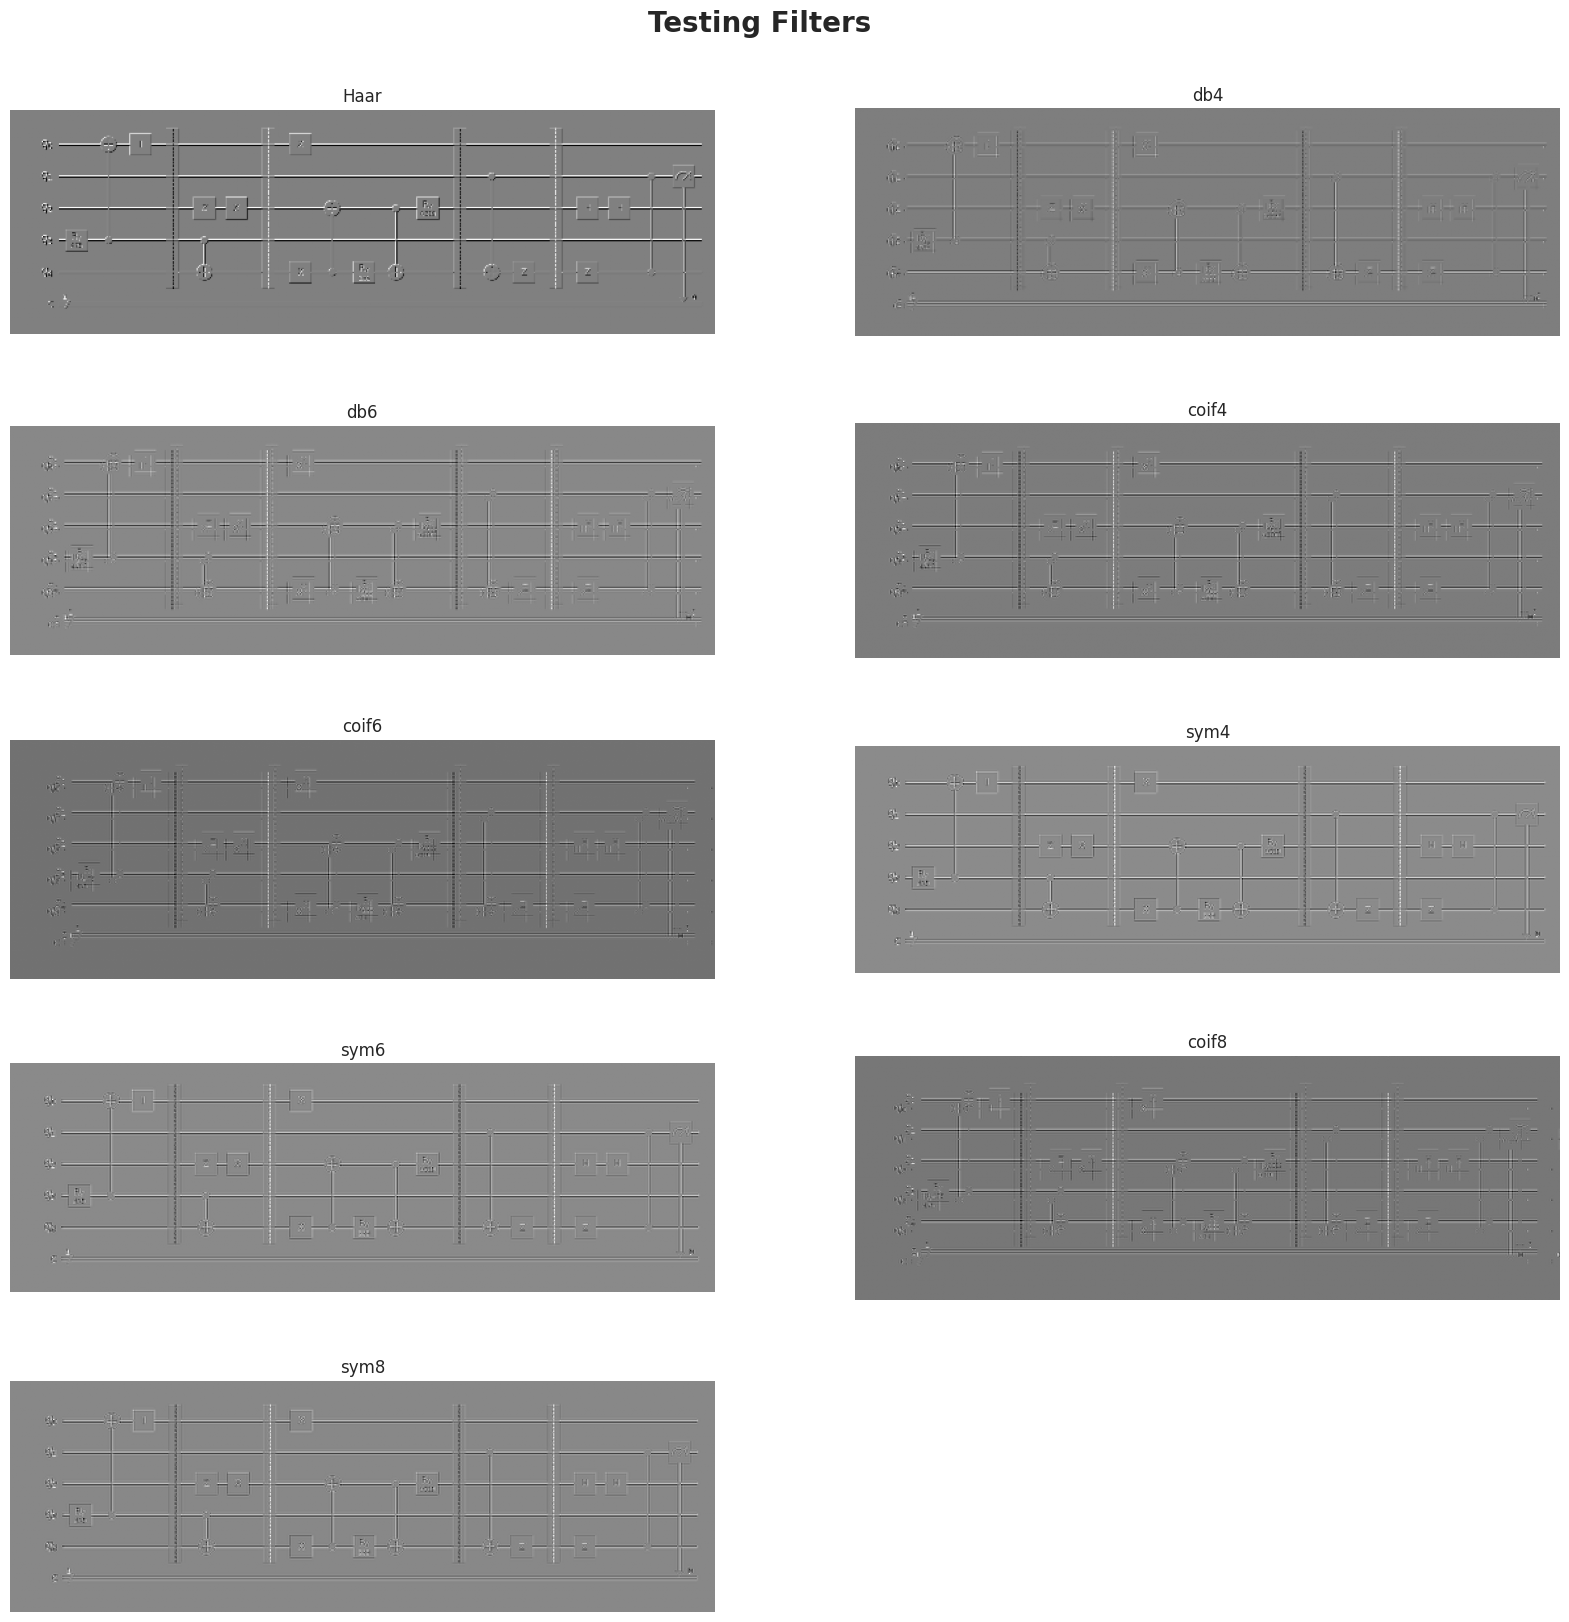

In [73]:
filters = ('Haar', "db4", "db6", "coif4", "coif6", "sym4", "sym6", "coif8", "sym8")
is_odd = len(filters) % 2 == 1
rows = int(len(filters)//2) + int(is_odd)
cols = 2

fig,axs = plt.subplots(rows,cols, figsize=(20,20))
if is_odd:
    axs[rows-1,cols-1].set_visible(False)


for f_i,f in enumerate(filters):
    coeffs = pywt.dwt2(ex_image, f)
    cA, (cB, cC, cD) = coeffs
    
    j = int(f_i % cols)
    i = int(f_i // cols)
    
    ax = axs[i,j]
    ax.imshow(cB+cC, cmap="grey")
    ax.set_title(f)
    ax.axis("off")

plt.suptitle("Testing Filters", y=0.92, fontsize=20, fontweight="bold")
fig.savefig(os.path.join(TARGET_DIR,"test-filters-borders.png"),bbox_inches="tight")
plt.show()


Summary: 
Original:  (170, 533)
With Pooling:  torch.Size([1, 1, 84, 266])


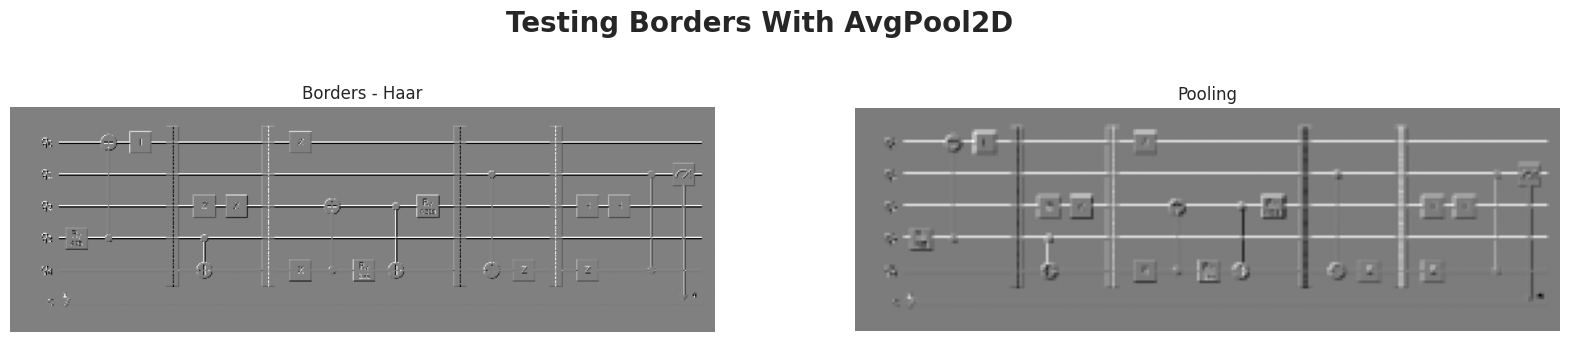

In [75]:
coeffs = pywt.dwt2(ex_image, 'Haar')
cA, (cB, cC, cD) = coeffs
border = cB+cC

pool = torch.nn.AvgPool2d(3, stride=2)
inp = torch.from_numpy(border).unsqueeze(0).unsqueeze(0)
border_pooled = pool(inp)

fig,axs = plt.subplots(1,2,figsize=(20,20))

print("Summary: ")
print("Original: ", border.shape)
print("With Pooling: ", border_pooled.shape)

axs[0].axis("off")
axs[0].set_title("Borders - Haar")
axs[0].imshow(border, cmap="grey")

axs[1].axis("off")
axs[1].set_title("Pooling")
axs[1].imshow(border_pooled.squeeze().numpy(), cmap="grey")

plt.suptitle("Testing Borders With AvgPool2D", y=0.6, fontsize=20, fontweight="bold")
fig.savefig(os.path.join(TARGET_DIR,"test-borders-avgpool.png"),bbox_inches="tight")
plt.show()

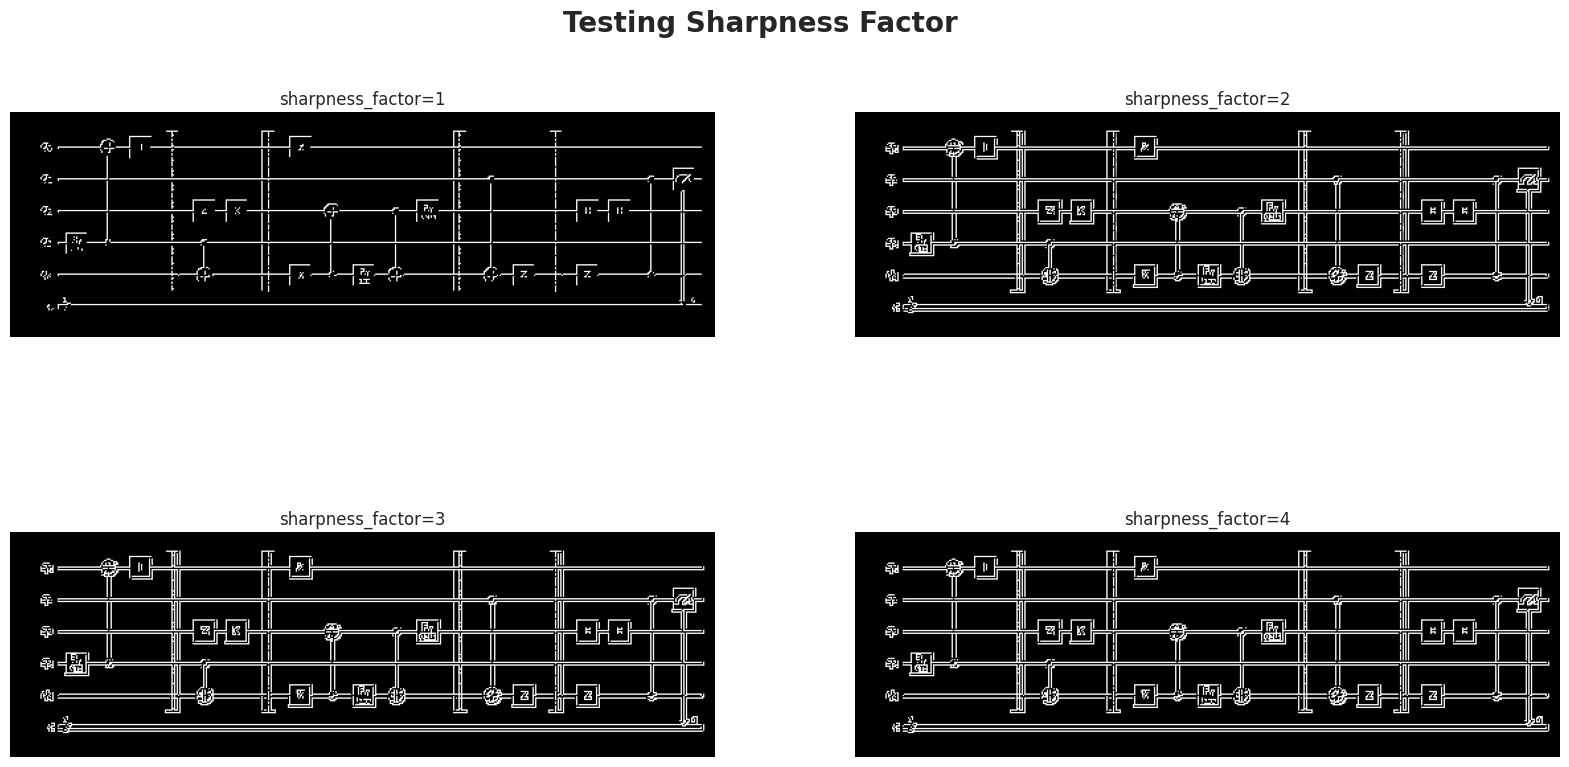

In [79]:
fig,axs = plt.subplots(2,2,figsize=(20,10))
for i in range(2):
    for j in range(2):
        factor = (i*2 + j) + 1
        filtering_v2 = v2.Compose([
            v2.RandomAdjustSharpness(sharpness_factor=factor, p=1)
        ])
        inp = torch.from_numpy(border).unsqueeze(0).unsqueeze(0)
        out = filtering_v2(inp).squeeze().numpy()
        axs[i,j].imshow(out, cmap="grey")
        axs[i,j].set_title(f"sharpness_factor={factor}")
        axs[i,j].axis("off")
plt.suptitle("Testing Sharpness Factor", y=0.92, fontsize=20, fontweight="bold")
fig.savefig(os.path.join(TARGET_DIR,"test-sharpness.png"),bbox_inches="tight")
plt.show()

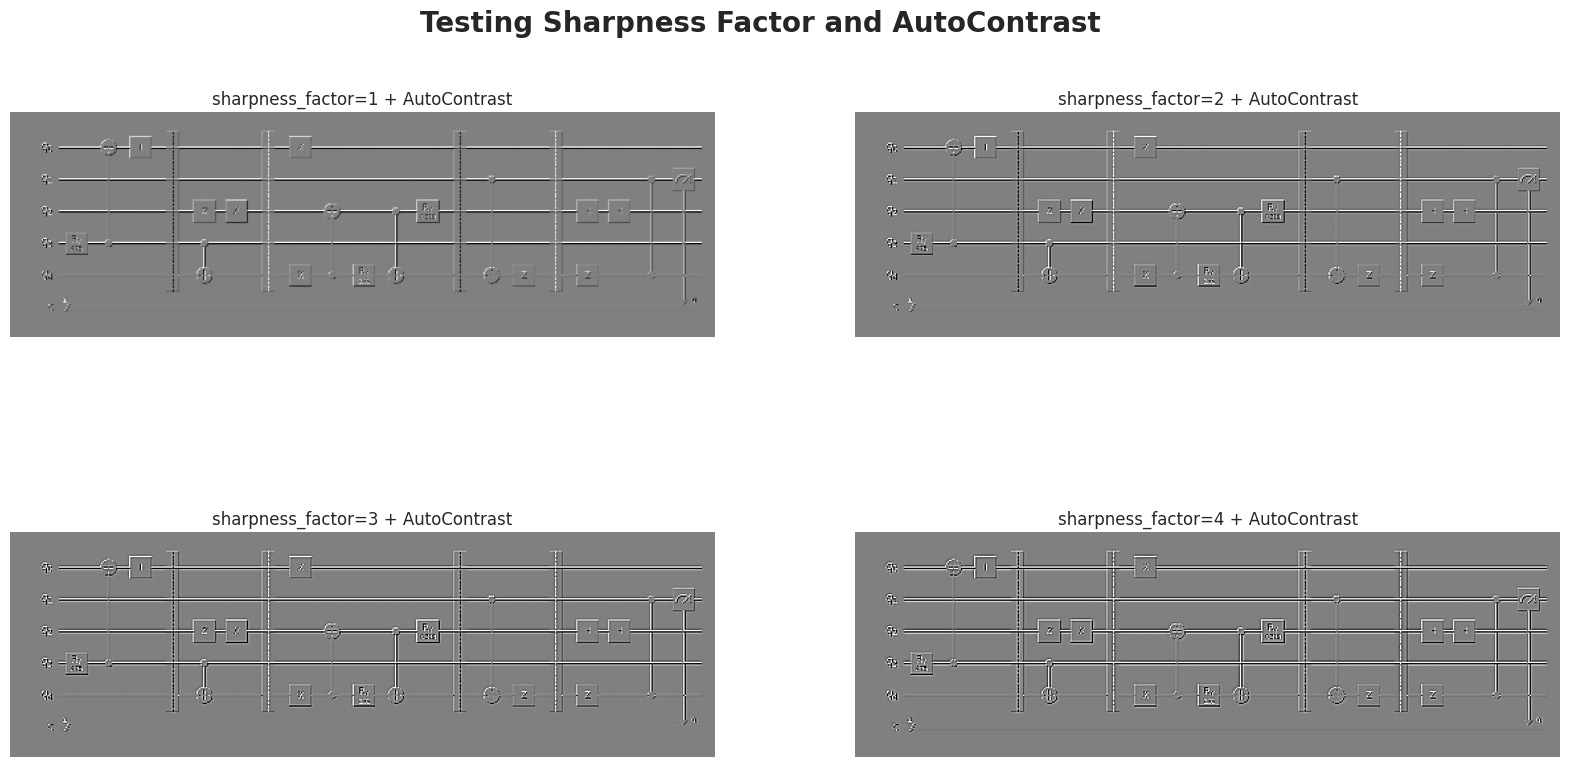

In [83]:
fig,axs = plt.subplots(2,2,figsize=(20,10))
for i in range(2):
    for j in range(2):
        factor = (i*2 + j) + 1
        filtering_v2 = v2.Compose([
            v2.RandomAutocontrast(p=1),
            v2.RandomAdjustSharpness(sharpness_factor=factor, p=1)
        ])
        inp = torch.from_numpy(border).unsqueeze(0).unsqueeze(0)
        out = filtering_v2(inp).squeeze().numpy()
        axs[i,j].imshow(out, cmap="grey")
        axs[i,j].set_title(f"sharpness_factor={factor} + AutoContrast")
        axs[i,j].axis("off")
plt.suptitle("Testing Sharpness Factor and AutoContrast", y=0.92, fontsize=20, fontweight="bold")
fig.savefig(os.path.join(TARGET_DIR,"test-sharpness-auto-contrast.png"),bbox_inches="tight")
plt.show()

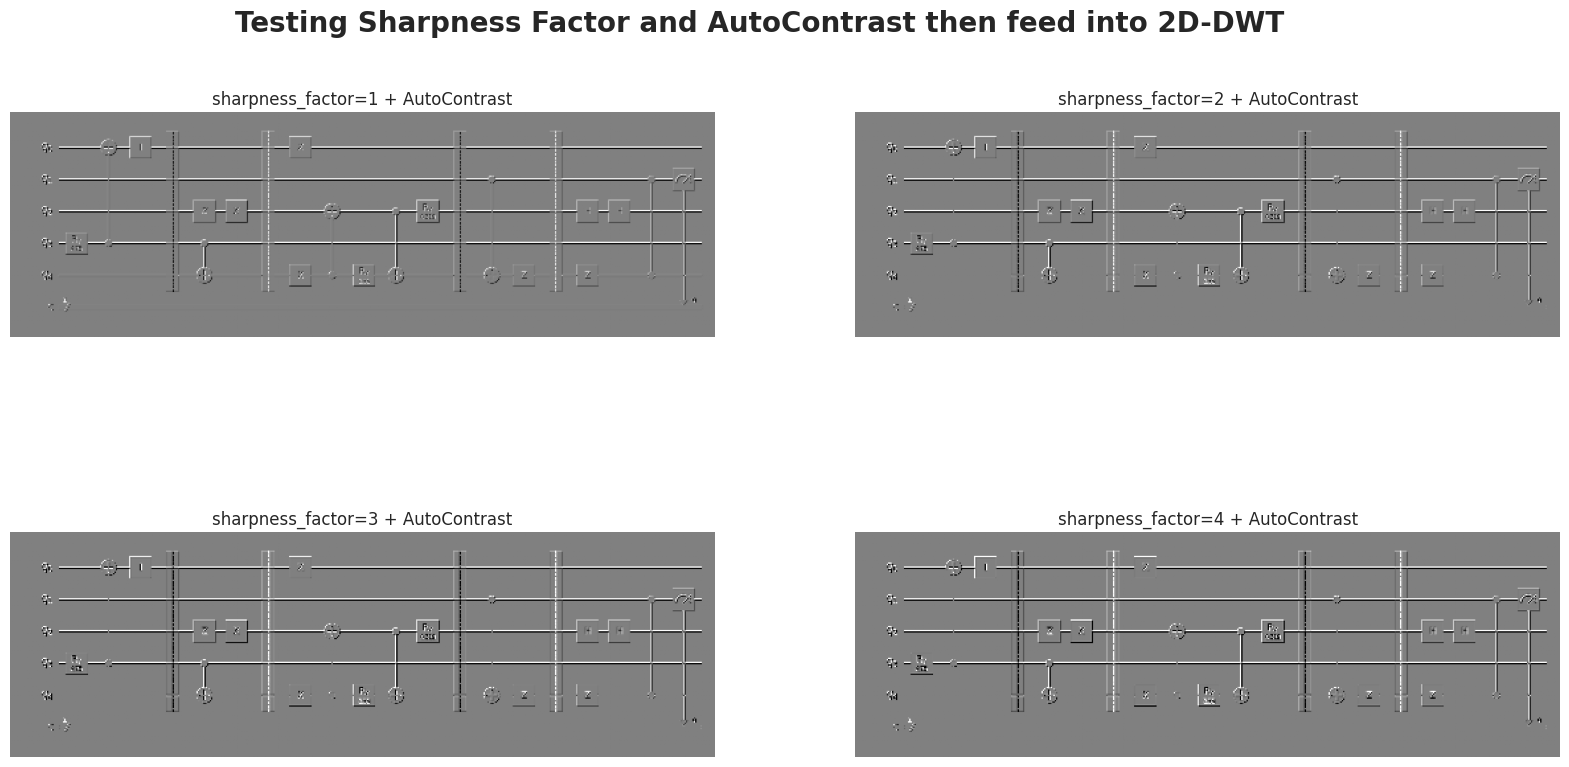

In [85]:
fig,axs = plt.subplots(2,2,figsize=(20,10))
for i in range(2):
    for j in range(2):
        factor = (i*2 + j) + 1
        filtering_v2 = v2.Compose([
            v2.RandomAutocontrast(p=1),
            v2.RandomAdjustSharpness(sharpness_factor=factor, p=1)
        ])
        inp = torch.from_numpy(ex_image).unsqueeze(0).unsqueeze(0)
        out = filtering_v2(inp).squeeze().numpy()
        
        coeffs = pywt.dwt2(out, 'Haar')
        cA, (cB, cC, cD) = coeffs
        border = cB+cC
        axs[i,j].imshow(border, cmap="grey")
        axs[i,j].set_title(f"sharpness_factor={factor} + AutoContrast")
        axs[i,j].axis("off")
plt.suptitle("Testing Sharpness Factor and AutoContrast then feed into 2D-DWT", y=0.92, fontsize=20, fontweight="bold")
fig.savefig(os.path.join(TARGET_DIR,"test-sharpness-auto-contrast-to-2D-DWT.png"),bbox_inches="tight")
plt.show()

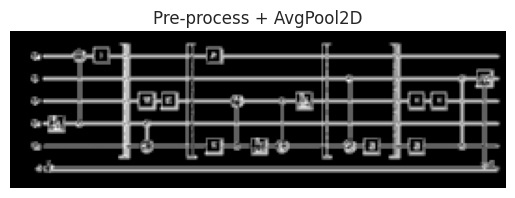

In [86]:
coeffs = pywt.dwt2(ex_image, 'Haar')
cA, (cB, cC, cD) = coeffs
border = cB+cC

filtering_v2 = v2.Compose([
            v2.RandomAdjustSharpness(sharpness_factor=2, p=1)
        ])
inp = torch.from_numpy(border).unsqueeze(0).unsqueeze(0)
out_v2 = filtering_v2(inp)
pool = torch.nn.AvgPool2d(3, stride=2)
border_pooled = pool(out_v2).squeeze().numpy()

plt.imshow(border_pooled,cmap="grey")
plt.title("Pre-process + AvgPool2D")
plt.axis("off")
plt.savefig(os.path.join(TARGET_DIR,"test-pre-processing-then-avgpool.png"),bbox_inches="tight")
plt.show()

Total unique values before:  141
Total unique values after:  2


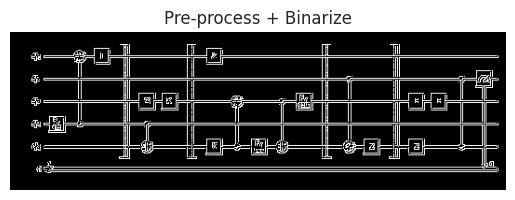

In [88]:
coeffs = pywt.dwt2(ex_image, 'Haar')
cA, (cB, cC, cD) = coeffs
border = cB+cC

filtering_v2 = v2.Compose([
            v2.RandomAdjustSharpness(sharpness_factor=2, p=1)
        ])
inp = torch.from_numpy(border).unsqueeze(0).unsqueeze(0)
out_v2 = filtering_v2(inp).squeeze().numpy()
out = (out_v2 > 0.5).astype(np.uint8)
print("Total unique values before: ", len(np.unique(out_v2))) 
print("Total unique values after: ", len(np.unique(out))) 
plt.imshow(out,cmap="grey")
plt.title("Pre-process + Binarize")
plt.axis("off")
plt.savefig(os.path.join(TARGET_DIR,"test-pre-processing-then-binarize.png"),bbox_inches="tight")
plt.show()